# 🔍 DIAGNÓSTICO — ¿Por qué los modelos no aprenden?

Ejecuta este notebook **sin tocar nada** y pega el output completo.  
El objetivo es entender exactamente qué tiene el dataset antes de cambiar código.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

base_dir = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')

print('base_dir:', base_dir)
print('Archivos en silver:')
for f in sorted(os.listdir(silver_dir)):
    size_mb = os.path.getsize(os.path.join(silver_dir, f)) / 1e6
    print(f'  {f:50s}  {size_mb:.1f} MB')

base_dir: /home/aitor/Documentos/ai-driven-cross-generator-transfer-learning
Archivos en silver:
  dataset_labeled.parquet                             52.3 MB
  fault_log.csv                                       3.6 MB
  fault_targets_grouped.parquet                       0.0 MB
  features_brake_hydro.parquet                        229.1 MB
  features_generator.parquet                          388.6 MB
  features_pitch_bat.parquet                          258.1 MB
  features_yaw_cable.parquet                          198.0 MB
  labeling_check.png                                  0.1 MB
  labeling_check_brake_hydro.png                      0.5 MB
  labeling_check_generator.png                        0.5 MB
  labeling_check_pitch_bat.png                        0.2 MB
  labeling_check_yaw_cable.png                        0.7 MB
  labeling_distribution.png                           0.1 MB
  technical_fault_catalog.csv                         0.0 MB
  turbine_1_telemetry_clean.parquet     

## 1. Distribución temporal de fallos reales

In [2]:
targets = pd.read_parquet(os.path.join(silver_dir, 'fault_targets_grouped.parquet'))
print(f'Total eventos agrupados: {len(targets)}')
print(f'Rango temporal: {targets["timestamp"].min()} → {targets["timestamp"].max()}')
print()
print('Eventos por familia:')
print(targets['family'].value_counts())
print()

# Corte del 80/20 temporal
labeled = pd.read_parquet(os.path.join(silver_dir, 'dataset_labeled.parquet'))
labeled = labeled.sort_values('timestamp').reset_index(drop=True)
cutoff = labeled['timestamp'].quantile(0.80)
print(f'Corte temporal 80/20: {cutoff}')
print(f'Rango telemetría: {labeled["timestamp"].min()} → {labeled["timestamp"].max()}')
print()

# Fallos en train vs test por familia
print('Fallos reales en TRAIN vs TEST (corte 80/20):')
print(f'{"Familia":<15} {"Train":>8} {"Test":>8} {"Total":>8}')
print('-' * 45)
for fam in ['yaw_cable', 'brake_hydro', 'generator', 'pitch_bat']:
    fam_events = targets[targets['family'] == fam]
    n_train = (fam_events['timestamp'] < cutoff).sum()
    n_test  = (fam_events['timestamp'] >= cutoff).sum()
    print(f'{fam:<15} {n_train:>8} {n_test:>8} {len(fam_events):>8}')

Total eventos agrupados: 330
Rango temporal: 2018-01-11 15:00:00 → 2021-12-30 07:10:00

Eventos por familia:
family
yaw_cable      187
brake_hydro     58
generator       55
pitch_bat       30
Name: count, dtype: int64

Corte temporal 80/20: 2021-03-14 18:04:00
Rango telemetría: 2017-12-31 23:00:00 → 2021-12-31 22:50:00

Fallos reales en TRAIN vs TEST (corte 80/20):
Familia            Train     Test    Total
---------------------------------------------
yaw_cable            146       41      187
brake_hydro           50        8       58
generator             49        6       55
pitch_bat             28        2       30


## 2. Desequilibrio real de clases en el dataset etiquetado

In [3]:
print('Desequilibrio de clases en dataset_labeled.parquet:')
print(f'{"Familia":<15} {"Total filas":>12} {"Positivos":>12} {"% Pos":>8} {"Lead time usado (h)":>22}')
print('-' * 75)

for fam in ['yaw_cable', 'brake_hydro', 'generator', 'pitch_bat']:
    col = f'is_pre_{fam}'
    n_pos = labeled[col].sum()
    n_total = len(labeled)
    pct = 100 * n_pos / n_total
    # Estimar lead time real a partir de las filas positivas
    hours_col = f'hours_to_{fam}'
    if hours_col in labeled.columns:
        max_lead = labeled[hours_col].max()
    else:
        max_lead = float('nan')
    print(f'{fam:<15} {n_total:>12,} {n_pos:>12,} {pct:>8.2f}% {max_lead:>22.1f}')

print()
print('NOTA: Lead time real = max(hours_to_familia) — debe coincidir con lo configurado en 04')

Desequilibrio de clases en dataset_labeled.parquet:
Familia          Total filas    Positivos    % Pos    Lead time usado (h)
---------------------------------------------------------------------------
yaw_cable            210,384      100,065    47.56%                  168.0
brake_hydro          210,384       21,185    10.07%                  120.0
generator            210,384       22,272    10.59%                  120.0
pitch_bat            210,384       28,753    13.67%                  336.0

NOTA: Lead time real = max(hours_to_familia) — debe coincidir con lo configurado en 04


## 3. Distribución temporal de positivos — ¿dónde están los fallos?

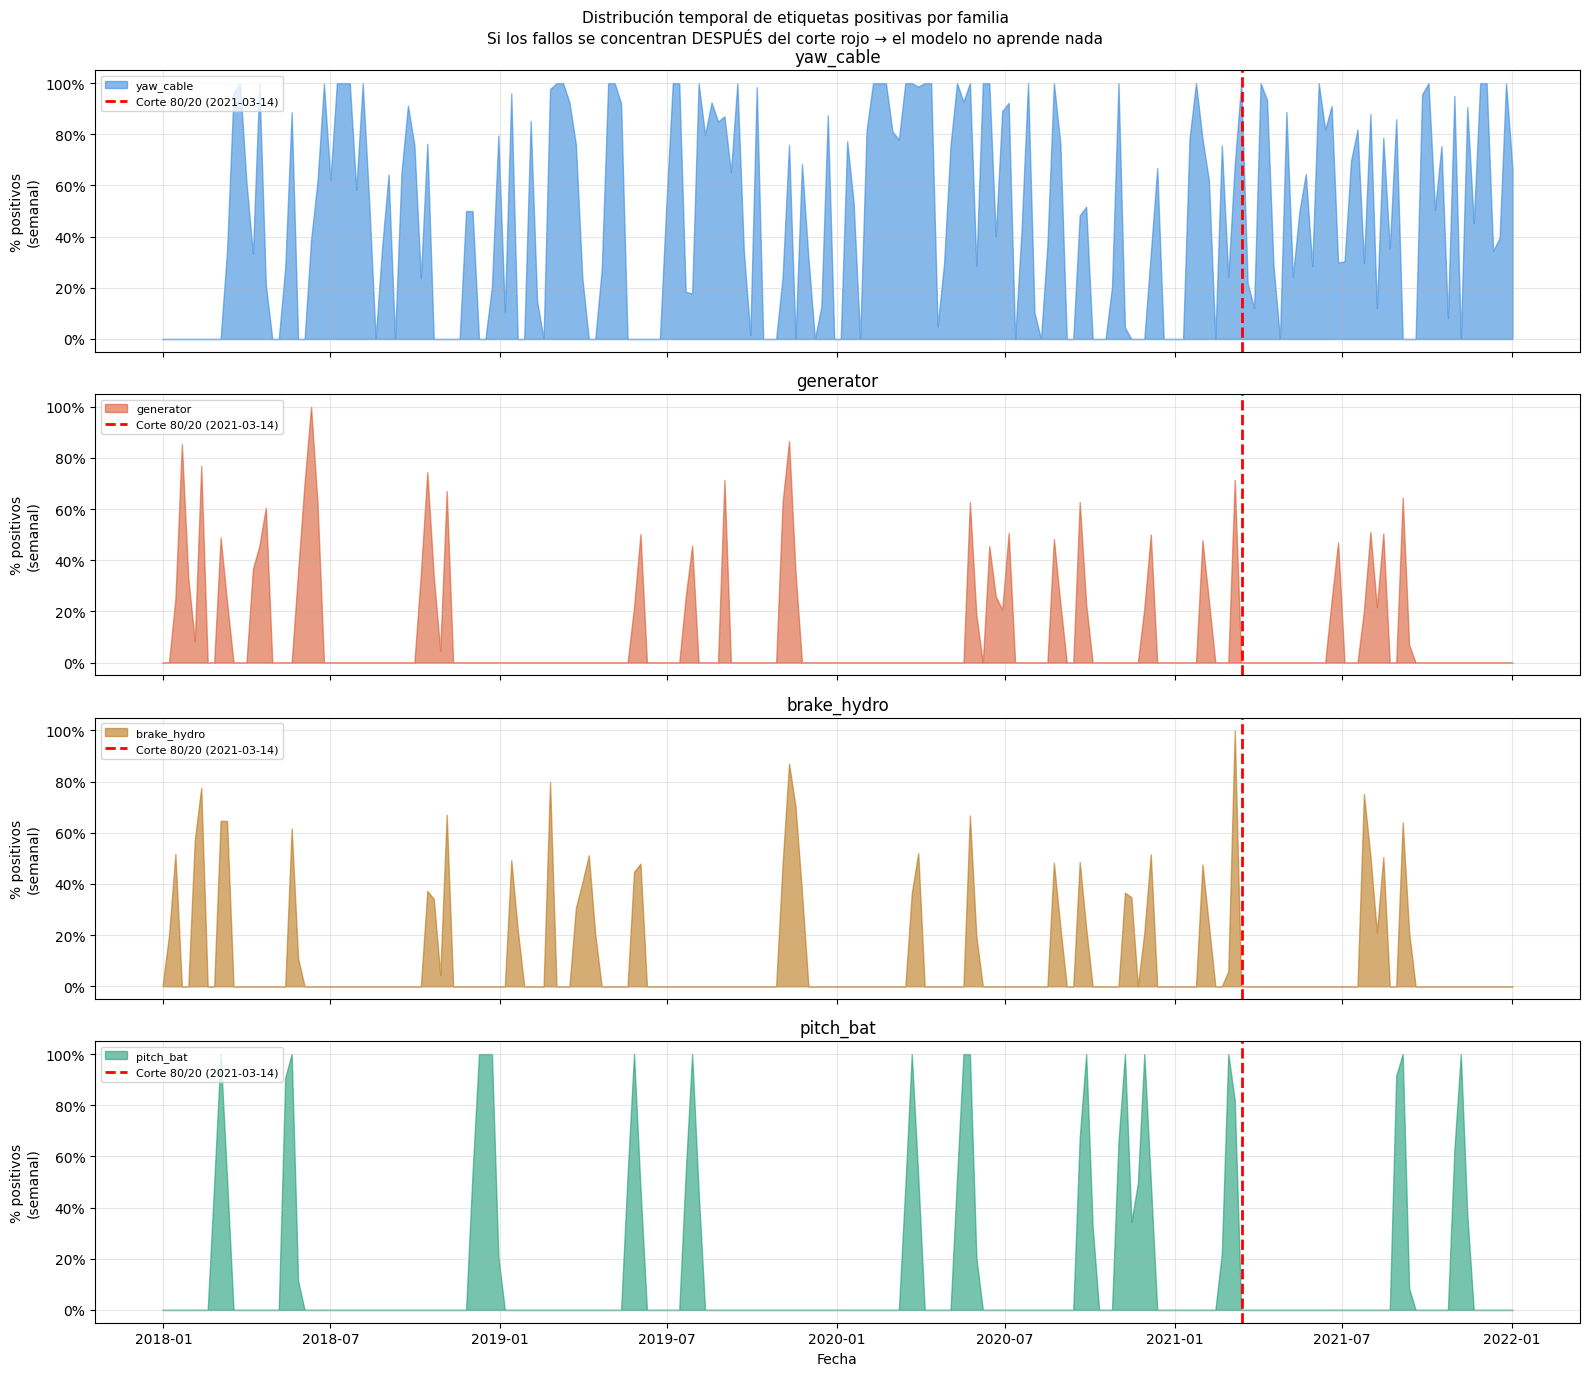

Guardado: diagnostico_distribucion_temporal.png


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

families = ['yaw_cable', 'generator', 'brake_hydro', 'pitch_bat']
colors = ['#378ADD', '#D85A30', '#BA7517', '#1D9E75']

# Resamplear a semanal para visualizar
labeled_plot = labeled.set_index('timestamp')

for ax, fam, color in zip(axes, families, colors):
    col = f'is_pre_{fam}'
    weekly = labeled_plot[col].astype(float).resample('W').mean()
    ax.fill_between(weekly.index, weekly.values, alpha=0.6, color=color, label=fam)
    ax.axvline(cutoff, color='red', linestyle='--', linewidth=2, label=f'Corte 80/20 ({cutoff.date()})')
    ax.set_ylabel('% positivos\n(semanal)')
    ax.set_title(fam)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

axes[-1].set_xlabel('Fecha')
fig.suptitle('Distribución temporal de etiquetas positivas por familia\n'
             'Si los fallos se concentran DESPUÉS del corte rojo → el modelo no aprende nada',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(silver_dir, 'diagnostico_distribucion_temporal.png'), dpi=150)
plt.show()
print('Guardado: diagnostico_distribucion_temporal.png')

## 4. Calidad de features — ¿el rolling genera NaNs o valores basura?

In [5]:
print('Calidad de features por familia (% de NaN y % de ceros):')
print()

for fam in ['yaw_cable', 'generator', 'brake_hydro', 'pitch_bat']:
    path = os.path.join(silver_dir, f'features_{fam}.parquet')
    if not os.path.exists(path):
        print(f'{fam}: archivo NO encontrado')
        continue
    
    feat = pd.read_parquet(path)
    feat_cols = [c for c in feat.columns if c not in ['timestamp', f'is_pre_{fam}', f'hours_to_{fam}']]
    
    n_nan  = feat[feat_cols].isna().sum().sum()
    n_zero = (feat[feat_cols] == 0).sum().sum()
    total  = feat[feat_cols].size
    
    # Top 5 columnas con más NaN
    nan_by_col = feat[feat_cols].isna().mean().sort_values(ascending=False).head(5)
    
    print(f'=== {fam} ===')
    print(f'  Shape: {feat.shape}')
    print(f'  NaN total: {n_nan:,} ({100*n_nan/total:.1f}%)')
    print(f'  Ceros total: {n_zero:,} ({100*n_zero/total:.1f}%)')
    print(f'  Top 5 cols con más NaN:')
    for col, pct in nan_by_col.items():
        print(f'    {col}: {pct*100:.1f}%')
    print()

Calidad de features por familia (% de NaN y % de ceros):

=== yaw_cable ===
  Shape: (210384, 147)
  NaN total: 586,920 (1.9%)
  Ceros total: 1,985,871 (6.6%)
  Top 5 cols con más NaN:
    cable_windings_from_calibration_point__slope_7d: 6.2%
    vane_position_12__slope_7d: 6.2%
    cable_windings_from_calibration_point__slope_24h: 4.6%
    vane_position_12__slope_24h: 4.6%
    nacelle_std_ratio__slope_7d: 4.5%

=== generator ===
  Shape: (210384, 255)
  NaN total: 1,369,061 (2.6%)
  Ceros total: 183,743 (0.3%)
  Top 5 cols con más NaN:
    generator_bearing_rear_temperature_max_c__slope_7d: 9.3%
    generator_bearing_front_temperature_max_c__slope_7d: 9.3%
    generator_bearing_front_temperature_max_c__slope_24h: 7.9%
    generator_bearing_rear_temperature_max_c__slope_24h: 7.9%
    generator_bearing_rear_temperature_max_c__slope_6h: 7.6%

=== brake_hydro ===
  Shape: (210384, 171)
  NaN total: 797,108 (2.3%)
  Ceros total: 4,705,442 (13.3%)
  Top 5 cols con más NaN:
    gear_oil_inle

## 5. Señal real en features — ¿los positivos son distintos de los negativos?

In [6]:
# Para cada familia, compara la distribución de las top 5 features
# entre clase positiva y negativa. Si son iguales → no hay señal.

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

print('AUC-ROC univariante (feature individual vs target):')
print('Si todas las features tienen AUC ~0.5 → no hay señal real en los datos')
print()

for fam in ['yaw_cable', 'generator', 'brake_hydro', 'pitch_bat']:
    path = os.path.join(silver_dir, f'features_{fam}.parquet')
    if not os.path.exists(path):
        continue
    
    feat = pd.read_parquet(path).sort_values('timestamp').reset_index(drop=True)
    target_col = f'is_pre_{fam}'
    feat_cols = [c for c in feat.columns if c not in ['timestamp', target_col, f'hours_to_{fam}']]
    
    y = feat[target_col].astype(int)
    
    if y.sum() == 0:
        print(f'{fam}: SIN POSITIVOS — el etiquetado no generó ningún positivo')
        continue
    
    # AUC univariante para cada feature
    aucs = {}
    for col in feat_cols:
        x = feat[col].fillna(0)
        try:
            auc = roc_auc_score(y, x)
            aucs[col] = max(auc, 1 - auc)  # symmetric AUC
        except:
            pass
    
    top5 = sorted(aucs.items(), key=lambda x: x[1], reverse=True)[:5]
    bottom5 = sorted(aucs.items(), key=lambda x: x[1])[:5]
    median_auc = np.median(list(aucs.values()))
    
    print(f'=== {fam} (positivos: {y.sum():,} / {len(y):,} = {100*y.mean():.2f}%) ===')
    print(f'  AUC mediana de todas las features: {median_auc:.3f}')
    print(f'  TOP 5 features con más señal:')
    for col, auc in top5:
        print(f'    {auc:.3f}  {col}')
    print(f'  PEORES 5 features (ruido puro):')
    for col, auc in bottom5:
        print(f'    {auc:.3f}  {col}')
    print()

AUC-ROC univariante (feature individual vs target):
Si todas las features tienen AUC ~0.5 → no hay señal real en los datos

=== yaw_cable (positivos: 100,065 / 210,384 = 47.56%) ===
  AUC mediana de todas las features: 0.516
  TOP 5 features con más señal:
    0.620  cable_windings_from_calibration_point__mean_7d
    0.608  nacelle_position_standard_deviation__mean_7d
    0.591  cable_windings_from_calibration_point__mean_24h
    0.590  cable_windings_from_calibration_point__mean_6h
    0.590  cable_windings_from_calibration_point__mean_1h
  PEORES 5 features (ruido puro):
    0.500  vane_position_12__slope_6h
    0.500  yaw_error_wind__slope_1h
    0.500  vane_position_12__slope_1h
    0.500  yaw_error__slope_1h
    0.500  nacelle_std_ratio__slope_1h

=== generator (positivos: 22,272 / 210,384 = 10.59%) ===
  AUC mediana de todas las features: 0.534
  TOP 5 features con más señal:
    0.668  generator_bearing_front_temperature_max_c__std_7d
    0.613  generator_bearing_front_temperatu

## 6. Inspeccion del split temporal — ¿cuántos positivos reales hay en test?

In [7]:
print('Positivos en TRAIN vs TEST (split 80/20 temporal):')
print(f'{"Familia":<15} {"Train pos":>10} {"Train %":>8} {"Test pos":>10} {"Test %":>8} {"Problema?":>12}')
print('-' * 70)

for fam in ['yaw_cable', 'generator', 'brake_hydro', 'pitch_bat']:
    path = os.path.join(silver_dir, f'features_{fam}.parquet')
    if not os.path.exists(path):
        continue
    
    feat = pd.read_parquet(path).sort_values('timestamp').reset_index(drop=True)
    target_col = f'is_pre_{fam}'
    
    cutoff_local = feat['timestamp'].quantile(0.80)
    train = feat[feat['timestamp'] < cutoff_local]
    test  = feat[feat['timestamp'] >= cutoff_local]
    
    tp = train[target_col].sum()
    tp_pct = 100 * tp / len(train) if len(train) > 0 else 0
    ep = test[target_col].sum()
    ep_pct = 100 * ep / len(test) if len(test) > 0 else 0
    
    problema = ''
    if tp == 0:
        problema = '❌ SIN TRAIN'
    elif ep == 0:
        problema = '❌ SIN TEST'
    elif tp < 100:
        problema = '⚠️ POCOS'
    else:
        problema = '✅ OK'
    
    print(f'{fam:<15} {tp:>10,} {tp_pct:>8.2f}% {ep:>10,} {ep_pct:>8.2f}% {problema:>12}')

Positivos en TRAIN vs TEST (split 80/20 temporal):
Familia          Train pos  Train %   Test pos   Test %    Problema?
----------------------------------------------------------------------
yaw_cable           76,776    45.62%     23,289    55.35%         ✅ OK
generator           19,384    11.52%      2,888     6.86%         ✅ OK
brake_hydro         18,334    10.89%      2,851     6.78%         ✅ OK
pitch_bat           24,727    14.69%      4,026     9.57%         ✅ OK


## 7. Verificación de posible data leakage — ¿el rolling usa datos futuros?

In [8]:
# Test: en la ventana 7d (1008 pasos), las primeras 1008 filas deberían tener
# valores calculados sobre menos pasos (min_periods = 1008//3 = 336 pasos mínimo).
# Si los primeros valores son muy altos → sospecha de leakage hacia atrás (no debería ocurrir)
# Si los primeros 336 valores son NaN → correcto, min_periods no se alcanzó aún

fam = 'yaw_cable'
path = os.path.join(silver_dir, f'features_{fam}.parquet')
feat = pd.read_parquet(path).sort_values('timestamp').reset_index(drop=True)

# Buscar una columna slope_7d
slope_cols = [c for c in feat.columns if 'slope_7d' in c]
mean_cols  = [c for c in feat.columns if 'mean_7d' in c]

print('Primeros valores de features 7d (deben ser NaN o pequeños hasta que se acumule ventana):')
if slope_cols:
    col = slope_cols[0]
    print(f'\n{col}:')
    print(feat[[col]].head(20).to_string())
    print(f'  Primer no-NaN en fila: {feat[col].first_valid_index()}')
    print(f'  Esperado: fila ~{1008//3} (min_periods=336)')

print()
print('Comprobación de que el rolling NO usa datos futuros:')
print('(el valor en fila N solo debe depender de filas < N)')
# Si el rolling es correcto, la pendiente 7d en el instante del fallo debe ser
# positiva para sensores que aumentan antes del fallo, no después.
# Verificamos con cable_windings para yaw_cable
if 'cable_windings_from_calibration_point__slope_7d' in feat.columns:
    labeled_ts = labeled[labeled['is_pre_yaw_cable']]['timestamp']
    if len(labeled_ts) > 0:
        first_fault_window_start = labeled_ts.iloc[0]
        window = feat[feat['timestamp'] == first_fault_window_start]
        val = window['cable_windings_from_calibration_point__slope_7d'].values
        print(f'cable_windings slope_7d en inicio primera ventana pre-fallo: {val}')
        print('  Esperado: valor positivo (cable acumulando vueltas → slope > 0)')
        print('  Si es 0 o negativo → señal débil o leakage')

Primeros valores de features 7d (deben ser NaN o pequeños hasta que se acumule ventana):

nacelle_position__slope_7d:
    nacelle_position__slope_7d
0                          NaN
1                          NaN
2                          NaN
3                          NaN
4                          NaN
5                          NaN
6                          NaN
7                          NaN
8                          NaN
9                          NaN
10                         NaN
11                         NaN
12                         NaN
13                         NaN
14                         NaN
15                         NaN
16                         NaN
17                         NaN
18                         NaN
19                         NaN
  Primer no-NaN en fila: 335
  Esperado: fila ~336 (min_periods=336)

Comprobación de que el rolling NO usa datos futuros:
(el valor en fila N solo debe depender de filas < N)
cable_windings slope_7d en inicio primera ventana pre-f

## 8. Resumen y diagnóstico final

In [9]:
print('=' * 70)
print('RESUMEN DE DIAGNÓSTICO')
print('=' * 70)
print()

# Lead times reales usados en el etiquetado
print('Lead times REALES en dataset_labeled (lo que realmente se usó en 04):')
for fam in ['yaw_cable', 'brake_hydro', 'generator', 'pitch_bat']:
    col = f'hours_to_{fam}'
    if col in labeled.columns:
        real_lead = labeled[col].max()
        n_events  = labeled[f'is_pre_{fam}'].sum()
        print(f'  {fam:<15}: max hours_to = {real_lead:.1f}h  → {int(real_lead/24)} días  ({n_events:,} filas positivas)')

print()
print('Número de FALLOS REALES (eventos únicos) por familia y período:')
for fam in ['yaw_cable', 'brake_hydro', 'generator', 'pitch_bat']:
    fam_t = targets[targets['family'] == fam].sort_values('timestamp')
    n_train = (fam_t['timestamp'] < cutoff).sum()
    n_test  = (fam_t['timestamp'] >= cutoff).sum()
    print(f'  {fam:<15}: {n_train} en train, {n_test} en test (corte: {cutoff.date()})')

print()
print('POSIBLES CAUSAS DE RESULTADOS MALOS (a confirmar con celdas anteriores):')
print('  A) Lead times muy cortos → pocas filas positivas → modelo no aprende el patrón previo')
print('  B) Fallos concentrados en el período de test → train sin suficientes positivos')
print('  C) Features con demasiados NaN o ceros → señal nula')
print('  D) AUC univariante ~0.5 en todas las features → los datos no contienen señal predictiva')
print()
print('Pega este output completo para continuar con el diagnóstico.')

RESUMEN DE DIAGNÓSTICO

Lead times REALES en dataset_labeled (lo que realmente se usó en 04):
  yaw_cable      : max hours_to = 168.0h  → 7 días  (100,065 filas positivas)
  brake_hydro    : max hours_to = 120.0h  → 5 días  (21,185 filas positivas)
  generator      : max hours_to = 120.0h  → 5 días  (22,272 filas positivas)
  pitch_bat      : max hours_to = 336.0h  → 14 días  (28,753 filas positivas)

Número de FALLOS REALES (eventos únicos) por familia y período:
  yaw_cable      : 146 en train, 41 en test (corte: 2021-03-14)
  brake_hydro    : 50 en train, 8 en test (corte: 2021-03-14)
  generator      : 49 en train, 6 en test (corte: 2021-03-14)
  pitch_bat      : 28 en train, 2 en test (corte: 2021-03-14)

POSIBLES CAUSAS DE RESULTADOS MALOS (a confirmar con celdas anteriores):
  A) Lead times muy cortos → pocas filas positivas → modelo no aprende el patrón previo
  B) Fallos concentrados en el período de test → train sin suficientes positivos
  C) Features con demasiados NaN o cer